# Project 2: Animal classification - Alisa Podolska, Yulian Kisil

In [1]:
import torch
torch.cuda.is_available()

False

In [2]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd 
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import random
from sklearn.model_selection import train_test_split
import shutil
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision import datasets
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F

## EDA

In [3]:
data_dir = "./dataset/raw-img"

### Translation (needed only first time)

In [4]:
mapping = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}
for old_name, new_name in mapping.items():
    old_path = os.path.join(data_dir, old_name)
    new_path = os.path.join(data_dir, new_name)

    if os.path.exists(old_path):
        os.rename(old_path, new_path)
    else:
        print(f"Folder'{old_name}' not found.")


Folder'cane' not found.
Folder'cavallo' not found.
Folder'elefante' not found.
Folder'farfalla' not found.
Folder'gallina' not found.
Folder'gatto' not found.
Folder'mucca' not found.
Folder'pecora' not found.
Folder'ragno' not found.
Folder'scoiattolo' not found.


In [5]:
classes = os.listdir(data_dir)
print("Classes:", classes)

for cls in classes:
    cnt = len(os.listdir(os.path.join(data_dir, cls)))
    print(f"{cls}: {cnt} images")

Classes: ['horse', 'cow', 'elephant', 'chicken', 'dog', 'cat', 'spider', 'butterfly', 'sheep', 'squirrel']
horse: 2623 images
cow: 1866 images
elephant: 1446 images
chicken: 3098 images
dog: 4863 images
cat: 1668 images
spider: 4821 images
butterfly: 2112 images
sheep: 1820 images
squirrel: 1862 images


### Visual sanity-chack

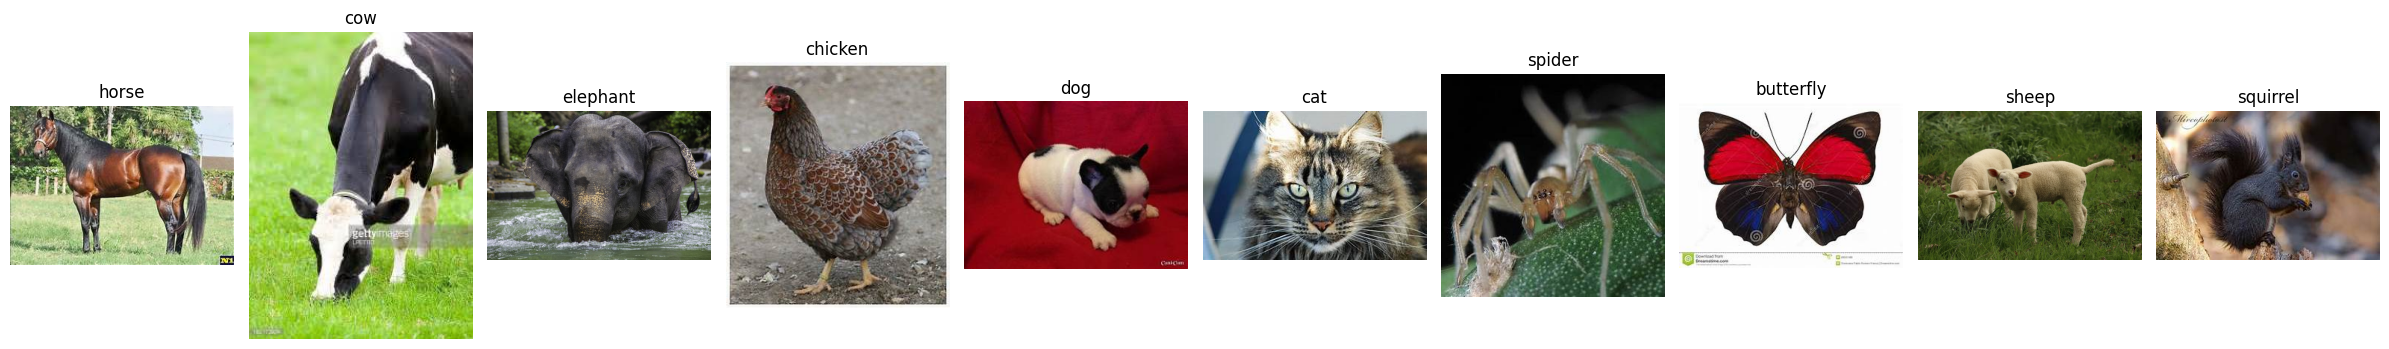

In [6]:
plt.figure(figsize=(24, 8))

for i, cls in enumerate(classes):
    cls_dir = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(cls_dir))
    img_path = os.path.join(cls_dir, img_name)
    
    img = Image.open(img_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Distribution

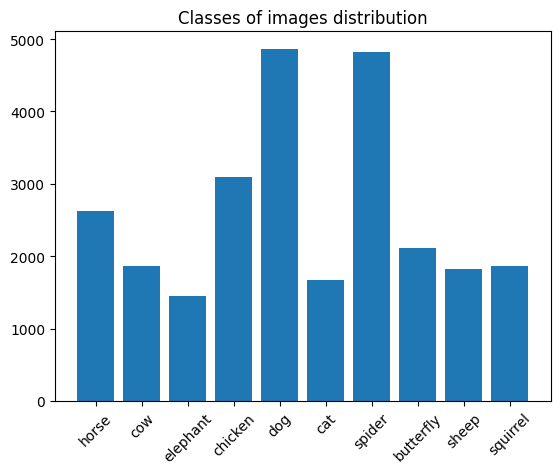

In [7]:
counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes}
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45)
plt.title("Classes of images distribution")
plt.show()

### Checking format, size and aspect-reisho

In [8]:
shapes=[]
channels=[]

for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir,cls))[:200]:
        img=Image.open(os.path.join(data_dir,cls,img_name))
        shapes.append(img.size);channels.append(img.mode)
        
shapes=np.array(shapes)
print("Avarage size:",shapes.mean(axis=0))
print("Min:",shapes.min(axis=0))
print("Max:",shapes.max(axis=0))
print("Channels:",set(channels))

Avarage size: [333.762  257.3825]
Min: [60 57]
Max: [6720 4608]
Channels: {'RGBA', 'RGB'}


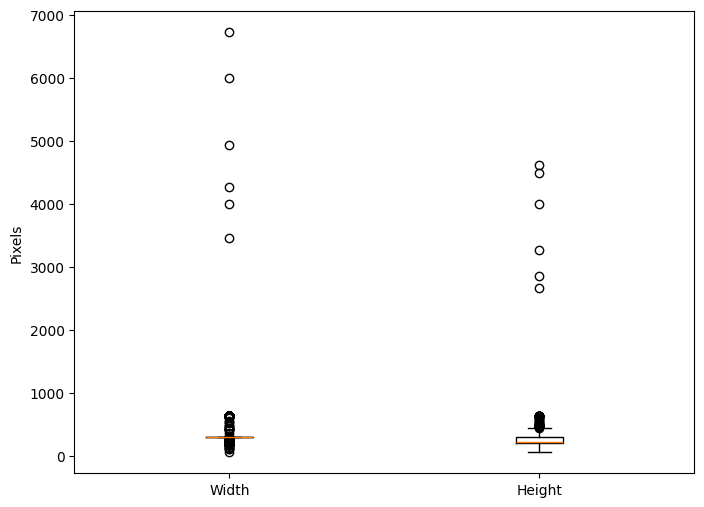

In [13]:

shapes = []
channels = []

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    for img_name in os.listdir(cls_path)[:200]:
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        shapes.append(img.size)
        channels.append(img.mode)

shapes = np.array(shapes)
widths = shapes[:, 0]
heights = shapes[:, 1]

plt.figure(figsize=(8, 6))
plt.boxplot([widths, heights], labels=["Width", "Height"], showfliers=True)
plt.ylabel("Pixels")
plt.show()

### Checking for broken images

In [14]:
bad = []
for cls in classes:
    for file in os.listdir(os.path.join(data_dir, cls)):
        path = os.path.join(data_dir, cls, file)
        try:
            Image.open(path).verify()
        except:
            bad.append(path)

bad

[]

## Data preprocessing

### Data split 
Train - 70  
Validation - 20  
Test - 10

In [15]:
train_dir = "dataset/train"
val_dir = "dataset/val"
test_dir = "dataset/test"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    images = os.listdir(os.path.join(data_dir, cls))
    train, test = train_test_split(images, test_size=0.1, random_state=42)
    train, val = train_test_split(train, test_size=0.2, random_state=42)

    for name in train:
        shutil.copy(os.path.join(data_dir, cls, name), os.path.join(train_dir, cls, name))

    for name in val:
        shutil.copy(os.path.join(data_dir, cls, name), os.path.join(val_dir, cls, name))

    for name in test:
        shutil.copy(os.path.join(data_dir, cls, name), os.path.join(test_dir, cls, name))

### Resize + mormalization

In [16]:
img_size = 224

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

### Data Augmentation (only for train)

In [17]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

The image is first resized, then randomly flipped horizontally to simulate mirrored views. A small random rotation is applied to introduce orientation variation. ColorJitter is used to slightly change brightness, contrast, and saturation, making the model less sensitive to lighting conditions. RandomResizedCrop selects and zooms into a random part of the image to help the model learn from different object scales and positions. Finally, the image is converted to a tensor and normalized using the standard ImageNet mean and standard deviation.

### Vizualisation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6897851..2.465708].


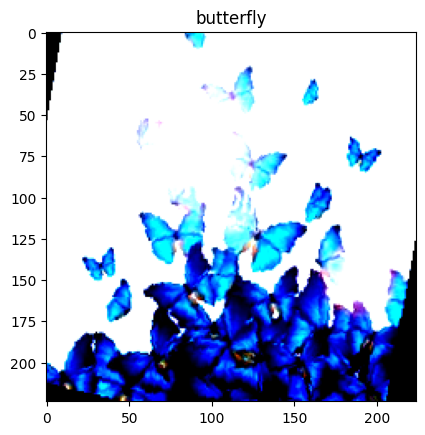

In [18]:
dataset = datasets.ImageFolder(train_dir, transform=train_transform)
img, label = dataset[0]

plt.imshow(img.permute(1,2,0))
plt.title(dataset.classes[label])
plt.show()


### DataLoader

In [19]:
train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds = datasets.ImageFolder(val_dir, transform=val_transform)
test_ds = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

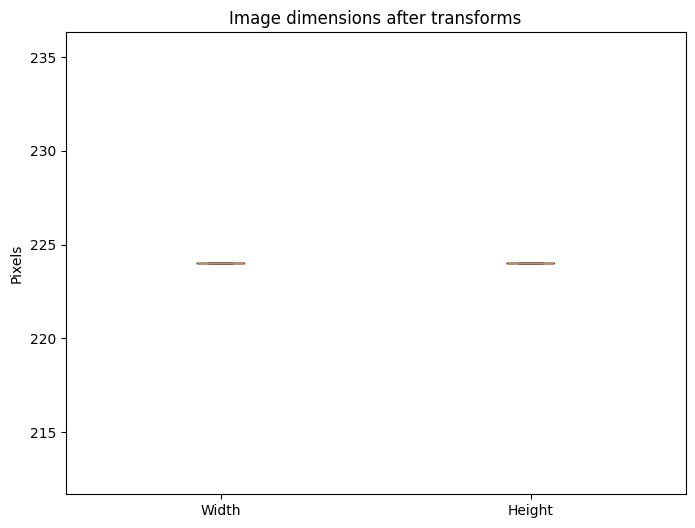

In [20]:
resized_widths = []
resized_heights = []

for img, _ in train_ds:      
    _, h, w = img.shape      
    resized_widths.append(w)
    resized_heights.append(h)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.boxplot([resized_widths, resized_heights], labels=["Width", "Height"], showfliers=True)
plt.title("Image dimensions after transforms")
plt.ylabel("Pixels")
plt.show()


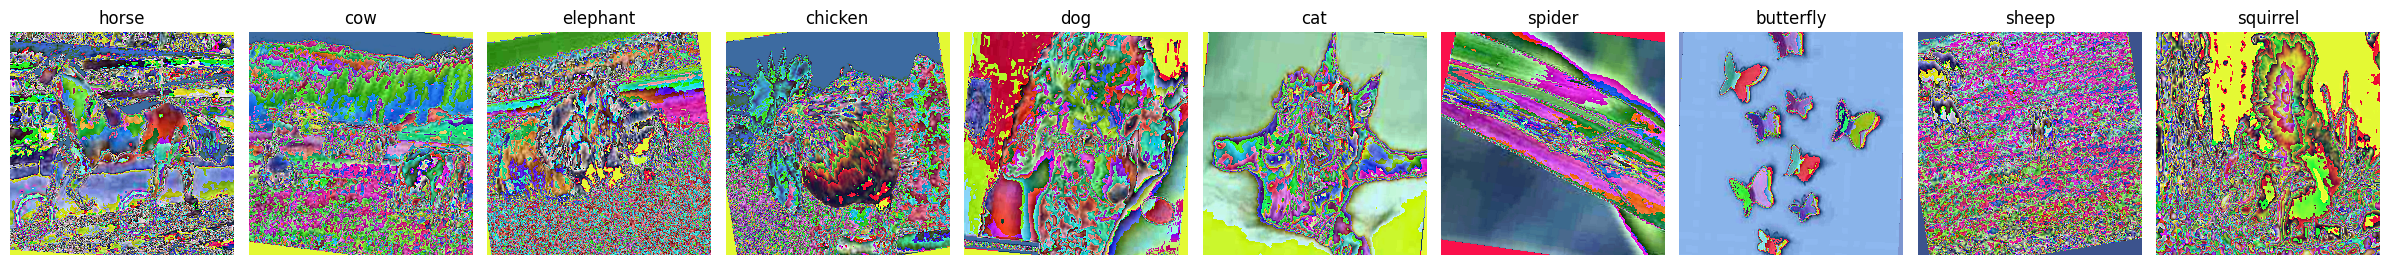

In [21]:
plt.figure(figsize=(24, 8))

for i, cls in enumerate(classes):
    class_idx = train_ds.class_to_idx[cls]
    indices = [j for j, (_, label) in enumerate(train_ds.samples) if label == class_idx]
    idx = random.choice(indices)

    img, _ = train_ds[idx]
    img = F.to_pil_image(img)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Week 2

### Model parametrs and architectures

### Our first small CNN

In [ ]:
img_size = 224
batch_size = 32
num_classes = 10
device = "cuda"
epochs = 30

In [ ]:
class animal_model(nn.Module):
    def __init__(self, num_classes):
        super(animal_model, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),            
        )

        # linear input: 256 * 14 * 14 = 50176
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
model = animal_model(num_classes).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

### Training

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)


### Validation

In [ ]:
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)


### First experiment 

In [ ]:
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = eval_epoch(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f" Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f" Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)


In [ ]:
test_loss, test_acc = eval_epoch(model, test_loader, criterion)
print(f"TEST ACC = {test_acc:.4f}")

### Wandb connection

In [ ]:
import os
os.environ["WANDB_SERVICE"] = "true"
os.environ["WANDB_DISABLE_CORE"] = "true"
os.environ["WANDB__SERVICE_WAIT"] = "300"
import wandb

In [ ]:
wandb.init(
    project="animalClassification",
    entity="xpodolskaa-stuba",
    settings=wandb.Settings(init_timeout=300),   
    config={
        "epochs": epochs,
        "batch_size": batch_size,
        "img_size": img_size,
        "optimizer": "adam",
        "lr": 1e-4,
        "architecture": "animal_model"
    }
)


wandb.watch(model, log="all", log_freq=10)

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f" Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f" Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)
    print("DEBUG: reached log point")  
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": float(train_loss),
        "train_acc": float(train_acc),
        "val_loss": float(val_loss),
        "val_acc": float(val_acc)
    })


## Week 3

### LeNet

In [ ]:
class LeNet(nn.Module):
    def __init__(self, num_classes):
        super(LeNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),   # 3 → 6
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(6, 16, kernel_size=5), # 6 → 16
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # 224 х 224
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 53 * 53, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
model = LeNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
epochs = 15
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")


### AlexNet

In [ ]:
from torchvision.models import alexnet

In [ ]:
def build_alexnet(num_classes):
    model = alexnet(weights="IMAGENET1K_V1")   # предобученные веса
    model.classifier[6] = nn.Linear(4096, num_classes)  # заменяем последний слой
    return model.to(device)


In [ ]:
model = build_alexnet(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] "
          f"Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")


### VGG-16

In [ ]:
from torchvision.models import vgg16


In [ ]:
def build_vgg16(num_classes):
    model = vgg16(weights="IMAGENET1K_V1") 
    model.classifier[6] = nn.Linear(4096, num_classes)

    return model.to(device)

In [ ]:
model = build_vgg16(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] "
          f"Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")

### Inception-v1 

In [ ]:
from torchvision.models import googlenet

In [ ]:
def build_inception_v1(num_classes):
    model = googlenet(weights="IMAGENET1K_V1", aux_logits=True)
    model.fc = nn.Linear(1024, num_classes)

    if model.aux_logits:
        model.aux1.fc2 = nn.Linear(1024, num_classes)
        model.aux2.fc2 = nn.Linear(1024, num_classes)

    return model.to(device)

In [ ]:
model = build_inception_v1(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train_epoch_inception(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        if isinstance(outputs, tuple):
            main_output, aux1_output, aux2_output = outputs

            loss1 = criterion(main_output, labels)
            loss2 = criterion(aux1_output, labels)
            loss3 = criterion(aux2_output, labels)

        
            loss = loss1 + 0.3 * loss2 + 0.3 * loss3
        else:
            loss = criterion(outputs, labels)
            main_output = outputs

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (main_output.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

In [ ]:
def eval_epoch_inception(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple): 
                outputs = outputs[0]

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

In [ ]:
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch_inception(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = eval_epoch_inception(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] "
          f"Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")

### ResNet-50

In [ ]:
from torchvision.models import resnet50

In [ ]:
def build_resnet50(num_classes):
    model = resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(2048, num_classes)
    
    return model.to(device)


In [ ]:
model = build_resnet50(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] "
          f"Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")


### DenseNet

In [ ]:
from torchvision.models import densenet121


In [ ]:
def build_densenet121(num_classes):
    model = densenet121(weights="IMAGENET1K_V1")  
    model.classifier = nn.Linear(1024, num_classes)

    return model.to(device)


In [ ]:
model = build_densenet121(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] "
          f"Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")

### MobileNet

In [ ]:
from torchvision.models import mobilenet_v2

In [ ]:
def build_mobilenet_v2(num_classes):
    model = mobilenet_v2(weights="IMAGENET1K_V1") 
    model.classifier[1] = nn.Linear(1280, num_classes)

    return model.to(device)


In [ ]:
model = build_mobilenet_v2(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] "
          f"Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")